# 차선 탐지 분류 모델

# Modules

In [1]:
#base
import matplotlib.pyplot as plt
import numpy as np 
import os, cv2, random, copy, time, math, shutil, sys, json
from PIL import Image
from shapely.geometry import LineString
from pathlib import Path
import urllib.request
import gc

#pytorch
import torch # torch.cuda.empty_cache()를 위해 함께 확인
import torchvision 
import torchvision.transforms as transforms 
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim 
from torch.nn import init
import torchvision.models as models
from torch.nn.utils.rnn import pack_padded_sequence
from torchvision.models import resnet18, resnet50, resnet101
from torch.utils.data import DataLoader, TensorDataset
from torch.autograd import Variable
from sklearn import datasets, model_selection
import torch.utils.data as data

# detectron2 (도커가 설치해뒀으니 그냥 불러오면 됨)
import tensorboardX
from detectron2.structures import BoxMode
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor, default_argument_parser, DefaultTrainer
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.utils.logger import setup_logger

# logger
setup_logger()

# 잘 불러와졌는지 확인용 (실행 시 버전 뜨면 성공)
print(f"Torhc Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

/usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Torhc Version: 2.10.0a0+b4e4ee81d3.nv25.12
CUDA Available: True


## gpu설정

In [2]:
import torch, detectron2
import sys, os, distutils.core

# 1. 버전 정보 확인
# !nvcc --version  # (주피터 매직 커맨드: 필요시 주석 해제하여 확인)
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print(f"torch: {TORCH_VERSION}; cuda: {CUDA_VERSION}")
print(f"detectron2: {detectron2.__version__}")

# 2. GPU 가용성 확인
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Count: {torch.cuda.device_count()}")

# 3. GPU 할당 및 확인
GPU_NUM = 0 # 5060 Ti 하나뿐이므로 0번 고정
device = torch.device(f'cuda:{GPU_NUM}' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    # [수정] set_device에는 device 객체('cuda:0')가 아니라 인덱스 숫자(0)를 넣는 것이 정석입니다.
    torch.cuda.set_device(GPU_NUM) 
    
    # [추가] 실제로 잡힌 GPU의 이름을 출력해서 5060 Ti가 맞는지 확인합니다.
    print('Current cuda device index:', torch.cuda.current_device())
    print('✅ Detected GPU:', torch.cuda.get_device_name(GPU_NUM)) 
else:
    print("❌ GPU를 찾을 수 없습니다.")

# 4. 메모리 할당 테스트
try:
    test_tensor = torch.rand(2).to(device)
    print("✅ Tensor Allocation Test Success:", test_tensor)
except Exception as e:
    print("❌ Tensor Allocation Failed:", e)

torch: 2.10; cuda: b4e4ee81d3.nv25.12
detectron2: 0.6
GPU Available: True
GPU Count: 1
Current cuda device index: 0
✅ Detected GPU: NVIDIA GeForce RTX 5060 Ti
✅ Tensor Allocation Test Success: tensor([0.8765, 0.1852], device='cuda:0')


## 필요함수 설정

In [ ]:
import os
import cv2
import json
import numpy as np
import shutil
import urllib.request
from pathlib import Path
from shapely.geometry import LineString
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.structures import BoxMode
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 시각화 함수 (그대로 유지)
# ---------------------------------------------------------
def draw_polygon(img_path, polygon_data):
    # (디버깅용이므로 실제 학습엔 영향 없음)
    if not os.path.exists(img_path): return
    img_array = np.fromfile(fr"{img_path}", np.uint8)
    image = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    imageLine = image.copy()
    polygon_data = [polygon_data]
    for poly in polygon_data:
        points = np.array(poly, np.int32)
        cv2.polylines(imageLine, [points], True, (0,255,0),2)
    plt.imshow(imageLine)
    plt.show()

# 2. 학습

def doTrain(class_, MetadataCatalog, categories, resume=True): # resume 인자 추가
    global cfg
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
    cfg.DATASETS.TRAIN = (f'{class_}_train',)
    cfg.DATASETS.TEST = () 
    cfg.DATALOADER.NUM_WORKERS = 4 # 데이터가 많으므로 워커를 4로 올려서 로딩 속도 향상
    cfg.SOLVER.IMS_PER_BATCH = 4 
    cfg.SOLVER.BASE_LR = 0.001 
    cfg.SOLVER.MAX_ITER = 42500     # 170k total 이미지
    cfg.SOLVER.CHECKPOINT_PERIOD = 5000 # 5,000번마다 자동 중간 저장
    cfg.SOLVER.STEPS = [30000, 40000]   # 학습 후반부에 학습률을 낮춰 더 정교하게 학습
    
    # ROI Heads 설정
    cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128  
    cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(categories)
    
    # 가중치 설정: resume이 True이면 마지막 체크포인트를 자동으로 찾습니다.
    if resume:
        # 마지막으로 학습하던 폴더 지정
        cfg.MODEL.WEIGHTS = os.path.join(f'./output/{class_}', "model_final.pth") 
    else:
        cfg.MODEL.WEIGHTS = str(Path("./temp/downloads/model.pkl"))

    cfg.OUTPUT_DIR = f'./output/{class_}'
    os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

    trainer = DefaultTrainer(cfg) 
    trainer.resume_or_load(resume=resume)   # True 일경우 모델 이어서 학습
    
    print(f"\n🚀 **************** {class_} 이어서 학습 시작 (목표: 42,500회) ****************************")
    trainer.train()
    
    # 모델 저장 로직
    save_dir = "./model_detectron"
    os.makedirs(save_dir, exist_ok=True)
    final_model_path = os.path.join(cfg.OUTPUT_DIR, 'model_final.pth')
    target_save_path = os.path.join(save_dir, f'model_{class_}.pth')
    
    if os.path.exists(final_model_path):
        shutil.copyfile(final_model_path, target_save_path)
        print(f"✅ 최종 모델 저장 완료: {target_save_path}")
    
    return trainer

# 3. Json 컴파일
def compile_json(json_path, img_path, categories):
    dataset_dicts = []
    idx = 1
    for root, _, files in os.walk(json_path):
        for json_file in files:
            try:
                with open(os.path.join(root, json_file), 'r', encoding='utf-8') as f:
                    data = json.load(f)
                
                # 메타데이터 추출
                meta = data.get("Meta", data.get("Annotation", {}).get("Image information", {}))
                width = int(meta.get("Width MAGNITUDE", meta.get("Image File Width", 1280)))
                height = int(meta.get("Height MAGNITUDE", meta.get("Image File Height", 720)))

                json_format = {
                    "file_name": os.path.join(root.replace('02.라벨링데이터', '01.원천데이터'), 
                                              json_file.replace('.json', '.jpg')),
                    "width": width, "height": height, "image_id": idx, "annotations": []
                }
                idx += 1
                
                for ann in data["Annotation"]['annotations']:
                    obj_name = ann.get("Object Name")
                    
                    if obj_name in categories:
                        # Polyline 또는 Polygon 데이터가 있는 경우
                        poly_raw = ann.get('Polyline', ann.get('Polygon'))
                        if poly_raw:
                            poly_data = poly_raw[0] if isinstance(poly_raw[0], list) else poly_raw
                            if len(poly_data) >= 6:
                                px, py = poly_data[::2], poly_data[1::2]
                                json_format["annotations"].append({
                                    "bbox": [min(px), min(py), max(px), max(py)], # XYXY 방식
                                    "bbox_mode": BoxMode.XYXY_ABS,
                                    "segmentation": [poly_data],
                                    "category_id": categories.index(obj_name)
                                })
                        
                        # Bbox Cordinate 데이터가 있는 경우(위반 차량 등)
                        elif "Bbox Cordinate" in ann:
                            bbox = ann["Bbox Cordinate"] # [x1, y1, x2, y2]
                            if len(bbox) == 4:
                                x1, y1, x2, y2 = bbox
                                # Mask R-CNN 학습을 위해 박스를 사각형 다각형으로 변환
                                dummy_poly = [x1, y1, x2, y1, x2, y2, x1, y2]
                                json_format["annotations"].append({
                                    "bbox": [x1, y1, x2, y2],
                                    "bbox_mode": BoxMode.XYXY_ABS,
                                    "segmentation": [dummy_poly],
                                    "category_id": categories.index(obj_name)
                                })
                                
                if json_format["annotations"]: 
                    dataset_dicts.append(json_format)
            except: 
                continue
                
    print(f"✅ 데이터 로드 완료: {len(dataset_dicts)}개")
    return dataset_dicts

# ---------------------------------------------------------
# 4. 데이터셋 등록 함수 (대소문자 수정 완료)
# ---------------------------------------------------------
def dataset_register_do_train(json_path, img_path, class_, categories): # 1. 여기서 categories를 받아서
    DatasetCatalog.clear()
    MetadataCatalog.clear()
    
    # [Train] 등록
    DatasetCatalog.register(f"{class_}_train", lambda: compile_json(json_path, img_path, categories))
    MetadataCatalog.get(f"{class_}_train").set(thing_classes=categories)
    
    # [Val] 등록
    val_json = json_path.replace('training', 'validation') 
    val_img = img_path.replace('training', 'validation')
    
    # categories를 전달합니다.
    DatasetCatalog.register(f"{class_}_val", lambda: compile_json(val_json, val_img, categories))
    MetadataCatalog.get(f"{class_}_val").set(thing_classes=categories)
    
    # doTrain 호출 시 categories 전달
    trainer = doTrain(class_, MetadataCatalog, categories)
    return trainer

In [ ]:
# 통합 모델 학습

In [11]:
# 1. 모든 항목 통합 카테고리 정의
all_categories = [
    '신호 위반 차량(이륜차 포함)', '적색 신호등 점등', '정지선',
    '중앙선 주황색 실선', '중앙선 주황색 이중실선', '중앙선침범 위반 차량(이륜차 포함)',
    '백색 실선 차선', '진로변경 위반 차량(이륜차 포함)',
    '횡단보도', '교차로 차량 운행 지역'
]

# 2. 통합할 데이터 폴더 및 데이터 수집
folders = ["신호위반", "중앙선침범", "진로변경위반"]
full_dataset = []

for folder in folders:
    j_path = f"/mnt/traffic/이미지데이터/training/02.라벨링데이터/{folder}"
    i_path = f"/mnt/traffic/이미지데이터/training/01.원천데이터/{folder}"
    print(f"📦 {folder} 데이터 수집 중...")
    # 기존 compile_json 함수를 사용하여 리스트에 추가
    full_dataset.extend(compile_json(j_path, i_path, all_categories))

# ---------------------------------------------------------
# 4. 데이터셋 등록 및 학습 실행 (에러 해결 핵심 구간)
# ---------------------------------------------------------
class_name = "Traffic_Unified"

from detectron2.data import DatasetCatalog, MetadataCatalog
# [중요] 기존 등록 정보를 삭제하여 중복 에러(AssertionError) 방지
DatasetCatalog.clear()
MetadataCatalog.clear()

# [중요] 비워진 카탈로그에 'Traffic_Unified_train'이라는 이름으로 17만 장 데이터를 등록
DatasetCatalog.register(f"{class_name}_train", lambda: full_dataset)
MetadataCatalog.get(f"{class_name}_train").set(thing_classes=all_categories)

print(f"✅ 데이터셋 등록 완료: {class_name}_train")

# [중요] 등록이 끝난 후 doTrain을 호출해야 KeyError가 나지 않습니다
trainer = doTrain(class_name, MetadataCatalog, all_categories, resume=True)

# 5. 메모리 정리
del trainer
gc.collect()
torch.cuda.empty_cache()

📦 신호위반 데이터 수집 중...
✅ 데이터 로드 완료: 76648개
📦 중앙선침범 데이터 수집 중...
✅ 데이터 로드 완료: 58786개
📦 진로변경위반 데이터 수집 중...
✅ 데이터 로드 완료: 34994개
✅ 데이터셋 등록 완료: Traffic_Unified_train
[01/28 04:14:13 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64

In [ ]:
# 통합 모델 예측

In [14]:
import os
import gc
import torch
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.data import MetadataCatalog, DatasetCatalog

# 1. 통합 카테고리 설정 (학습 때와 동일해야 함)
all_categories = [
    '신호 위반 차량(이륜차 포함)', '적색 신호등 점등', '정지선',
    '중앙선 주황색 실선', '중앙선 주황색 이중실선', '중앙선침범 위반 차량(이륜차 포함)',
    '백색 실선 차선', '진로변경 위반 차량(이륜차 포함)',
    '횡단보도', '교차로 차량 운행 지역'
]

class_name = "Traffic_Unified"

# 2. 설정 초기화 및 구축
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

# 3. 데이터셋 등록 (테스트용 이미지 경로 설정)
# (이미 데이터셋이 등록되어 있다면 clear 후 다시 등록)
DatasetCatalog.clear()
MetadataCatalog.clear()

# 임의의 테스트 경로 (하나만 지정해도 통합 모델이 다 찾아냅니다)
test_json = "/mnt/traffic/이미지데이터/validation/02.라벨링데이터/신호위반"
test_img = "/mnt/traffic/이미지데이터/validation/01.원천데이터/신호위반"

DatasetCatalog.register(f"{class_name}_val", lambda: compile_json(test_json, test_img, all_categories))
MetadataCatalog.get(f"{class_name}_val").set(thing_classes=all_categories)

# 4. 모델 가중치 로드 (방금 성공적으로 저장된 통합 모델 파일)
cfg.MODEL.WEIGHTS = "./final_model_save/model_Traffic_Unified.pth"
cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(all_categories) # 10개 클래스
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5 # 50% 이상 확신할 때만 표시

# 예측기 생성
predictor = DefaultPredictor(cfg)
print("✅ 통합 모델 예측기 준비 완료!")

[01/28 13:59:35 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./final_model_save/model_Traffic_Unified.pth ...
✅ 통합 모델 예측기 준비 완료!


In [ ]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
evaluator = COCOEvaluator(f'{class_}_val', cfg, False, output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, f'{class_}_val')
stopline_map = inference_on_dataset(predictor.model, val_loader, evaluator)

## 진로변경위반

# image_test

# 신호위반

✅ 파일을 찾았습니다: 20230223_적색신호시직진_0000011920_01.jpg


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

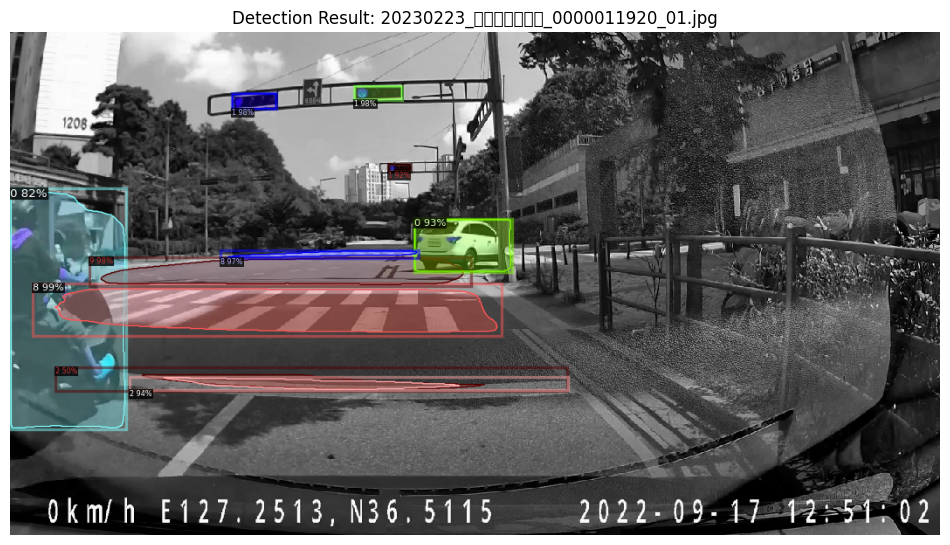

In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog

# 1. 대상 폴더 경로 (사용자님이 주신 경로)
target_dir = "/mnt/traffic/이미지데이터/validation/01.원천데이터/신호위반/적색신호시직진/20230223_적색신호시직진_0000011920"

# 2. 해당 폴더에서 실제 파일 목록 가져오기
if os.path.exists(target_dir):
    file_list = [f for f in os.listdir(target_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(file_list) > 0:
        # 첫 번째 파일을 선택합니다.
        img_name = file_list[0]
        img_path = os.path.join(target_dir, img_name)
        print(f"✅ 파일을 찾았습니다: {img_name}")
        
        # 3. 이미지 읽기 (한글 경로 대응)
        img_array = np.fromfile(img_path, np.uint8)
        im = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

        # 4. 통합 모델 예측 실행
        outputs = predictor(im) 


        # 5. 시각화 (Traffic_Unified_train 메타데이터 사용)
        # 학습 시 사용했던 'Traffic_Unified_train' 이름을 그대로 써야 합니다.
        v = Visualizer(im[:, :, ::-1],
                       metadata=MetadataCatalog.get("Traffic_Unified_train"), 
                       scale=0.8, 
                       instance_mode=ColorMode.IMAGE_BW)

        out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

        # 6. 결과 출력
        plt.figure(figsize=(12, 12))
        plt.imshow(out.get_image()[:, :, ::-1])
        plt.title(f"Detection Result: {img_name}")
        plt.axis("off")
        plt.show()
    else:
        print(f"❌ 폴더 안에 이미지 파일이 없습니다: {target_dir}")
else:
    print(f"❌ 경로 자체가 존재하지 않습니다: {target_dir}")
    print("도커 실행 시 마운트한 경로(/mnt/traffic)가 맞는지 다시 확인해주세요.")

In [ ]:
im = cv2.imread("/mnt/traffic/이미지데이터/신호위반/적색신호시직진/20230225_적색신호시직진_0000000147/20230225_적색신호시직진_0000000147_04.jpg")
outputs = predictor(im)  
v = Visualizer(im[:, :, ::-1],
               metadata=MetadataCatalog.get(f'{class_}_train'),
               scale=0.5, 
               instance_mode=
               2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
plt.figure(figsize=(10,10))
plt.imshow(out.get_image()[:, :, ::-1])
plt.show()

# 중앙선침범

In [ ]:
im = cv2.imread("/mnt/data1/traffic/교통데이터/Test/이미지데이터/중앙선침범/중앙선주황색실선위반/20230227_중앙선주황색실선위반_0000000068/20230227_중앙선주황색실선위반_0000000068_005.jpg")
outputs = predictor(im)  
v = Visualizer(im[:, :, ::-1],
               metadata=MetadataCatalog.get(f'{class_}_train'),
               scale=0.5, 
               instance_mode=
               2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
plt.figure(figsize=(10,10))
plt.imshow(out.get_image()[:, :, ::-1])
plt.show()

# 진로변경위반

In [ ]:
im = cv2.imread("/mnt/data1/traffic/교통데이터/Test/이미지데이터/진로변경위반/일반도로진로변경위반/20230227_일반도로진로변경위반_0000002138/20230227_일반도로진로변경위반_0000002138_04.jpg")
outputs = predictor(im)  
v = Visualizer(im[:, :, ::-1],
               metadata=MetadataCatalog.get(f'{class_}_train'),
               scale=0.5, 
               instance_mode=
               2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
plt.figure(figsize=(10,10))
plt.imshow(out.get_image()[:, :, ::-1])
plt.show()

## 교통영역

In [ ]:
im = cv2.imread("/mnt/data1/traffic/교통데이터/Test/이미지데이터/신호위반/적색신호시직진/20230225_적색신호시직진_0000000164/20230225_적색신호시직진_0000000164_05.jpg")
outputs = predictor(im)  
v = Visualizer(im[:, :, ::-1],
               metadata=MetadataCatalog.get(f'{class_}_val'),
               scale=0.5, 
               instance_mode=
               2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
plt.figure(figsize=(10,10))
plt.imshow(out.get_image())
# plt.imshow(im[:,:,::-1])

plt.show()